# Figure 3B — where each guide module sits in the embedding

:::{important}
Run `00_BuildGuideModuleObject.ipynb` first. It writes
`outputs/adata_SingleKO_GuideModules.h5ad`, which this notebook reads. That
notebook derives the per-cell guide-module indicators `K_0` … `K_5` and
`K_CONTROL` from the same screen object the other figure notebooks use.
:::

Each cell carries a guide against a gene in exactly one module. This notebook
asks where those cells sit in the UMAP: it estimates the density of each
module over the embedding, contrasts it with the density of the control cells,
and writes one panel per group.

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import seaborn as sns  # noqa: F401  registers the 'vlag' colormap used below
from IPython.display import display

%matplotlib inline

sc.set_figure_params(dpi=100, fontsize=12)
sc.settings.verbosity = "hint"

In [2]:
INPUT_H5AD = Path("outputs/adata_SingleKO_GuideModules.h5ad")
FIGURE_DIR = Path("figures"); FIGURE_DIR.mkdir(exist_ok=True)

# the guide modules, plus the control cells they are compared against
GROUPS = ["K_0", "K_1", "K_2", "K_3", "K_4", "K_5", "K_CONTROL"]
MODULES = [g for g in GROUPS if g != "K_CONTROL"]

PANEL_SIZE = (5.2, 5)

## Load

The indicators are categorical for `embedding_density`, which groups on them;
`"1"` is the category meaning *this cell belongs to the group*.

In [3]:
adata = sc.read(INPUT_H5AD)
for group in GROUPS:
    adata.obs[group] = adata.obs[group].astype(str).astype("category")

print(f"{adata.shape[0]} cells x {adata.shape[1]} genes")
print(adata.obs[GROUPS].apply(lambda col: (col == "1").sum()).to_string())

170393 cells x 1041 genes
K_0          31903
K_1          25219
K_2          23512
K_3          24037
K_4           6685
K_5           2805
K_CONTROL    56232


## How the modules distribute over the clusters

Not used by the figure, but worth seeing: how many cells of each module fall in
each leiden cluster.

In [4]:
perCluster = pd.concat(
    {group: adata.obs.loc[adata.obs[group] == "1", "leiden"].value_counts() for group in GROUPS},
    axis=1,
).T.sort_index(axis=1)
perCluster

,0,1,2,3,4,5,6,7,8,9
K_0,10359,7382,6084,3671,1898,863,782,533,312,19
K_1,7542,5064,5838,3480,1167,713,651,456,278,30
K_2,6934,5366,4462,3263,1516,713,613,326,293,26
K_3,7005,6058,4187,4043,896,583,509,346,338,72
K_4,2527,1382,1409,404,404,193,206,113,47,0
K_5,867,751,586,253,139,86,60,46,17,0
K_CONTROL,16822,12976,11257,8094,2448,1629,1305,935,711,55


## Module membership on the embedding

## Density of each group over the embedding

A Gaussian kernel density estimate over the UMAP coordinates, computed
separately for each group.

In [6]:
for group in GROUPS:
    sc.tl.embedding_density(adata, groupby=group)

computing density on 'umap'
--> added
    'umap_density_K_0', densities (adata.obs)
    'umap_density_K_0_params', parameter (adata.uns)
computing density on 'umap'
--> added
    'umap_density_K_1', densities (adata.obs)
    'umap_density_K_1_params', parameter (adata.uns)
computing density on 'umap'
--> added
    'umap_density_K_2', densities (adata.obs)
    'umap_density_K_2_params', parameter (adata.uns)
computing density on 'umap'
--> added
    'umap_density_K_3', densities (adata.obs)
    'umap_density_K_3_params', parameter (adata.uns)
computing density on 'umap'
--> added
    'umap_density_K_4', densities (adata.obs)
    'umap_density_K_4_params', parameter (adata.uns)
computing density on 'umap'
--> added
    'umap_density_K_5', densities (adata.obs)
    'umap_density_K_5_params', parameter (adata.uns)
computing density on 'umap'
--> added
    'umap_density_K_CONTROL', densities (adata.obs)
    'umap_density_K_CONTROL_params', parameter (adata.uns)


## Each module relative to the controls

The difference between a module's density and the control density says where
that module is over- or under-represented, rather than simply where cells are.

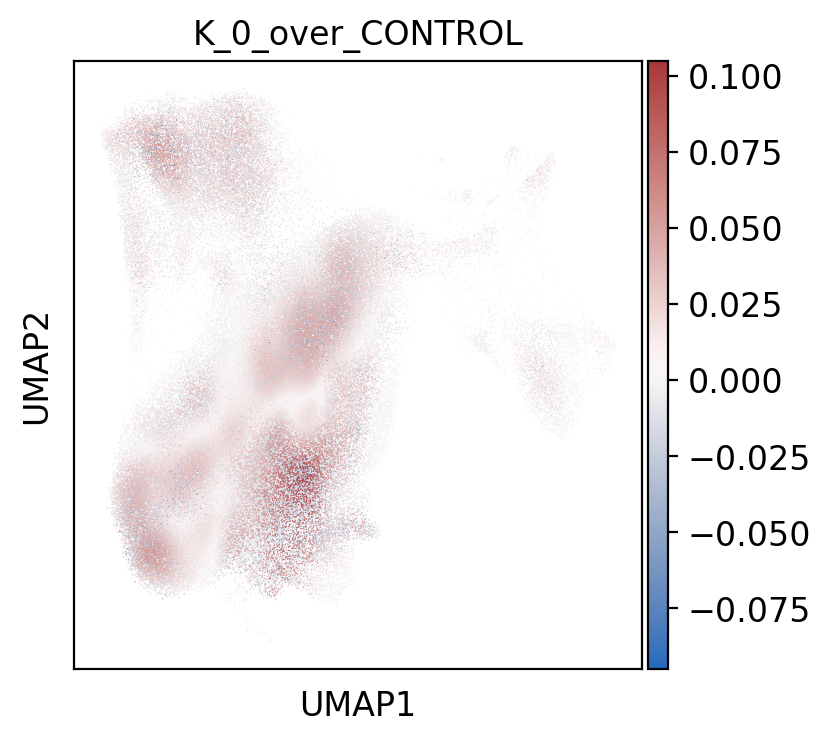

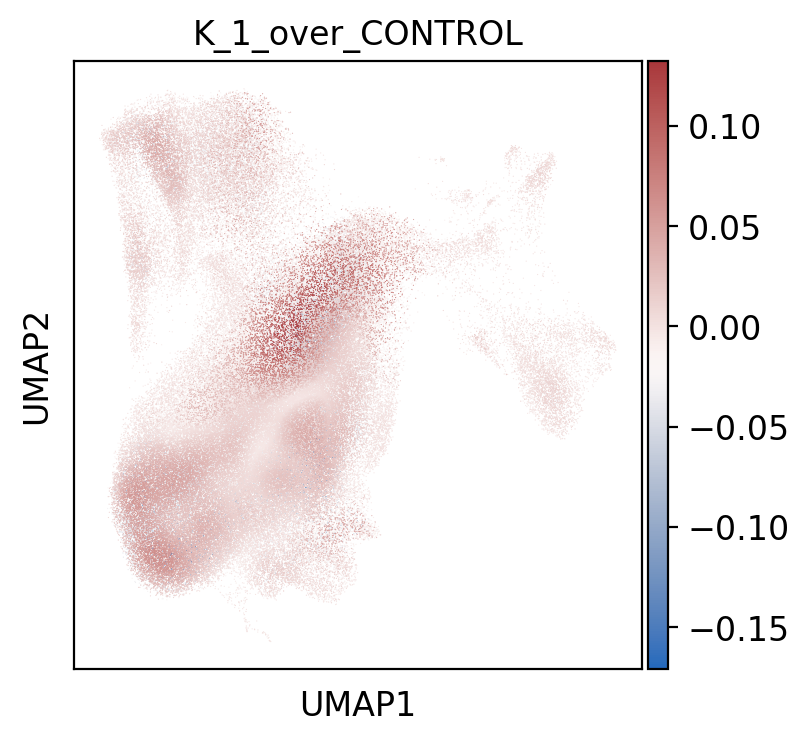

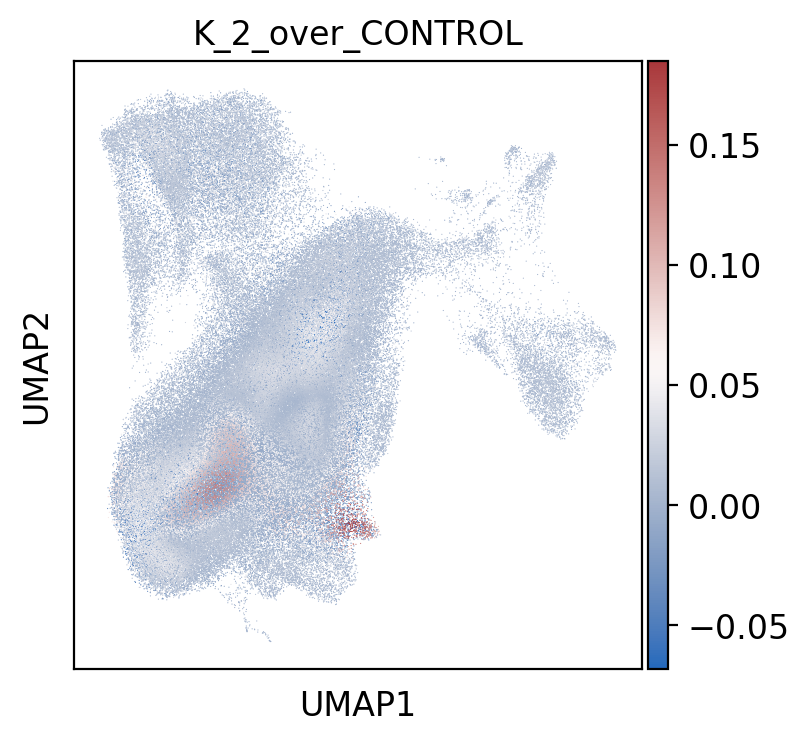

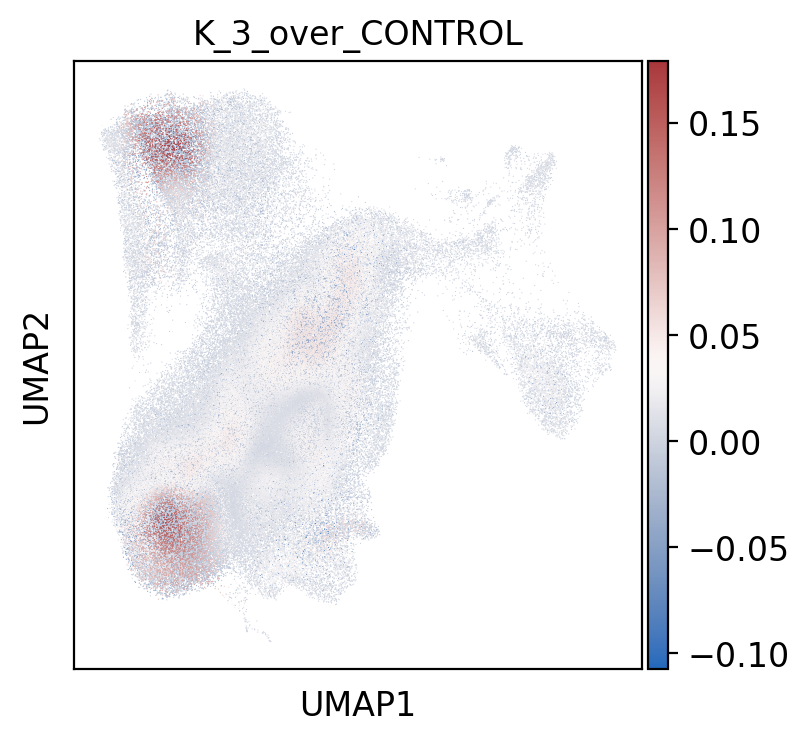

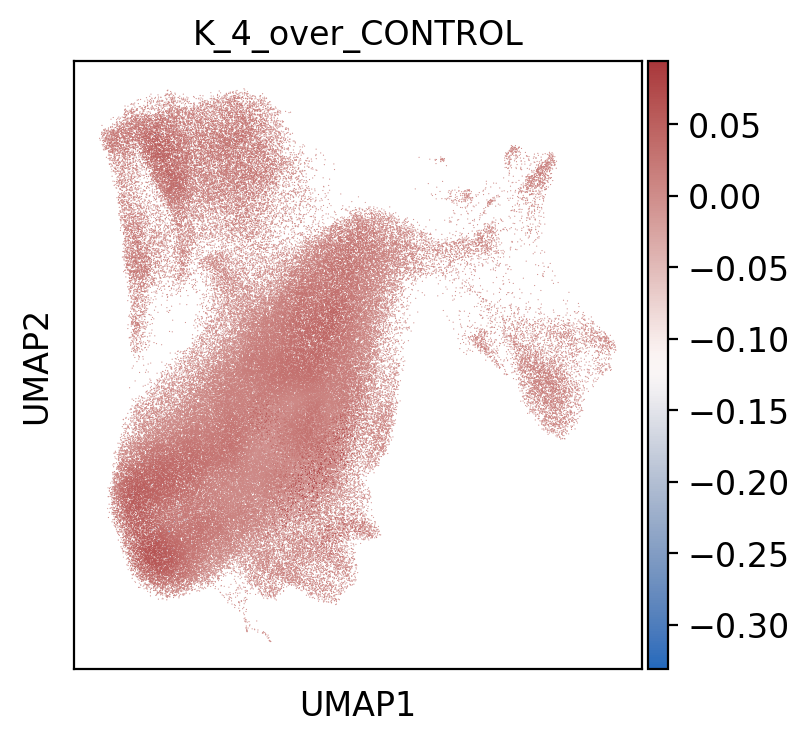

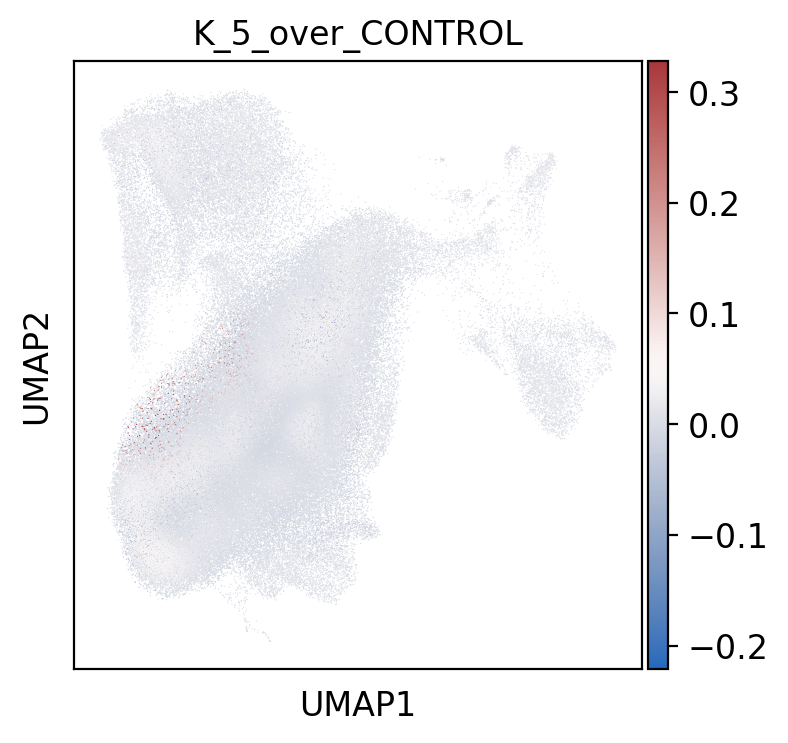

In [7]:
control = adata.obs["umap_density_K_CONTROL"].values
for module in MODULES:
    adata.obs[f"{module}_over_CONTROL"] = adata.obs[f"umap_density_{module}"].values - control

for module in MODULES:
    sc.pl.umap(adata, color=f"{module}_over_CONTROL", color_map="vlag")

## Density panels

One panel per group, controls included, shown here and written to `figures/`.

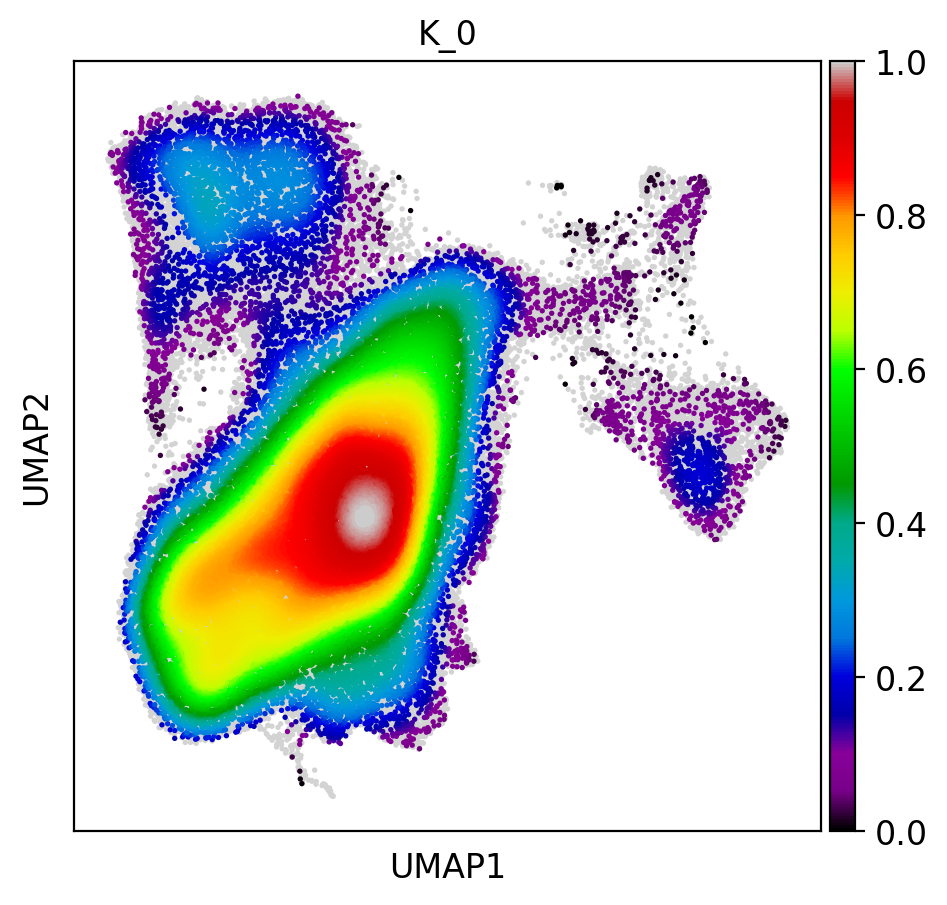

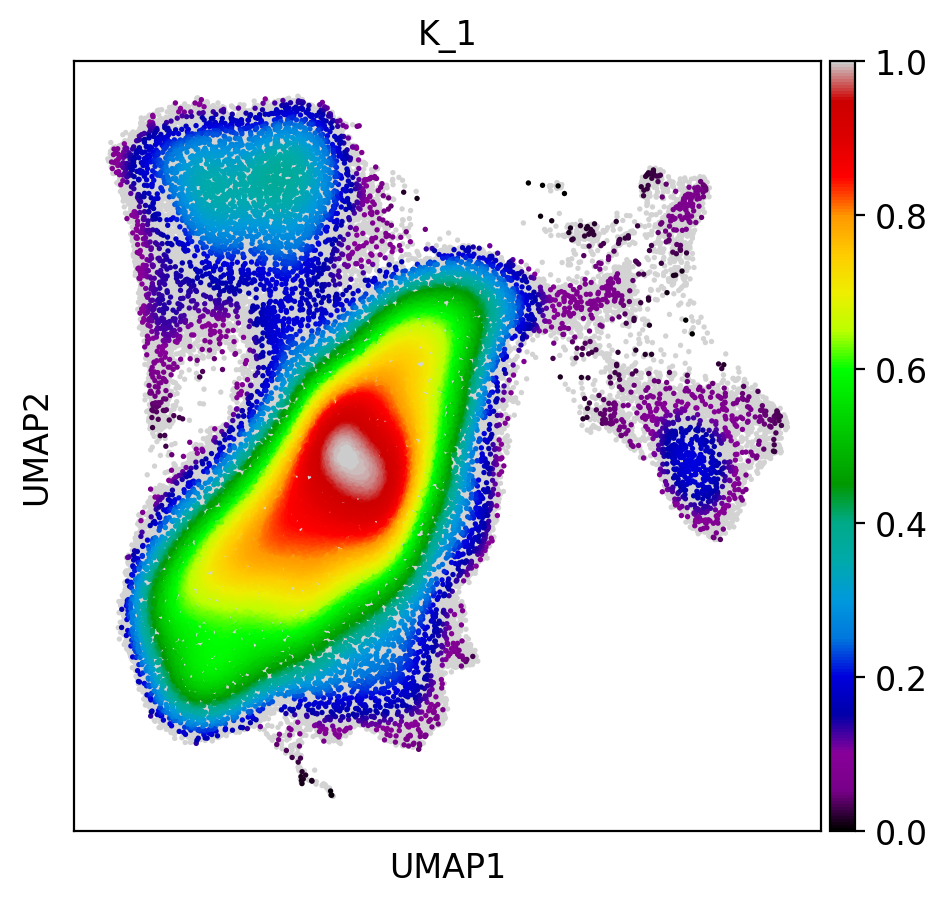

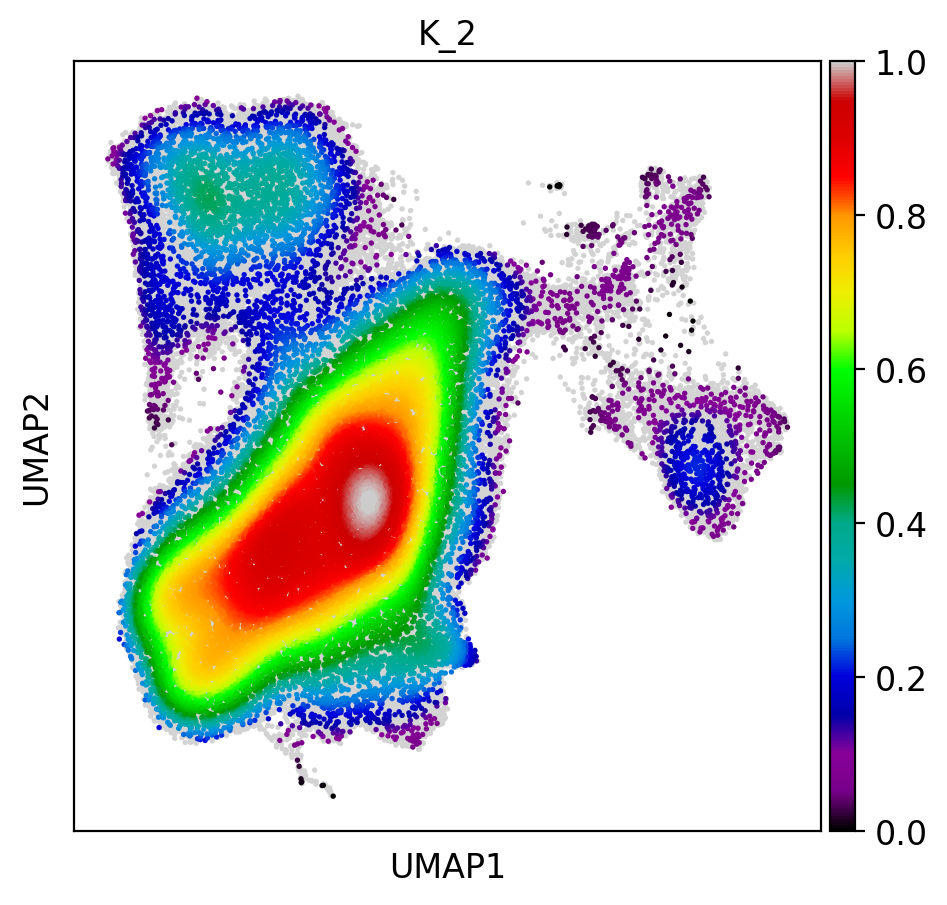

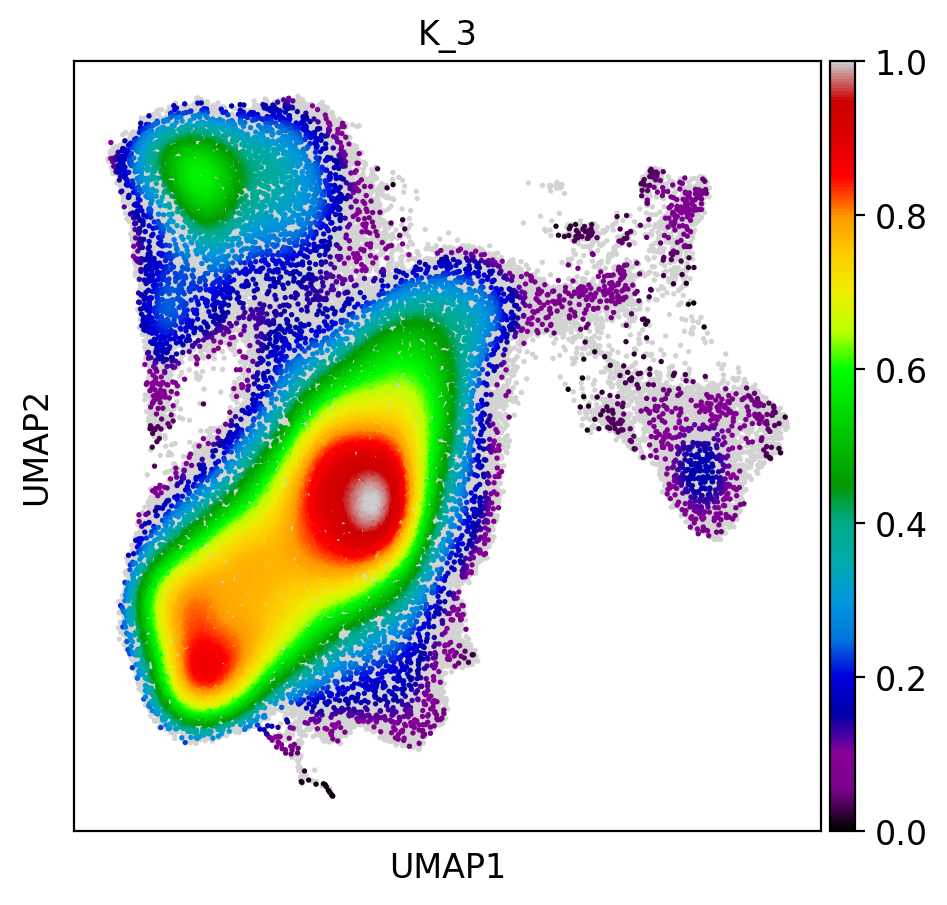

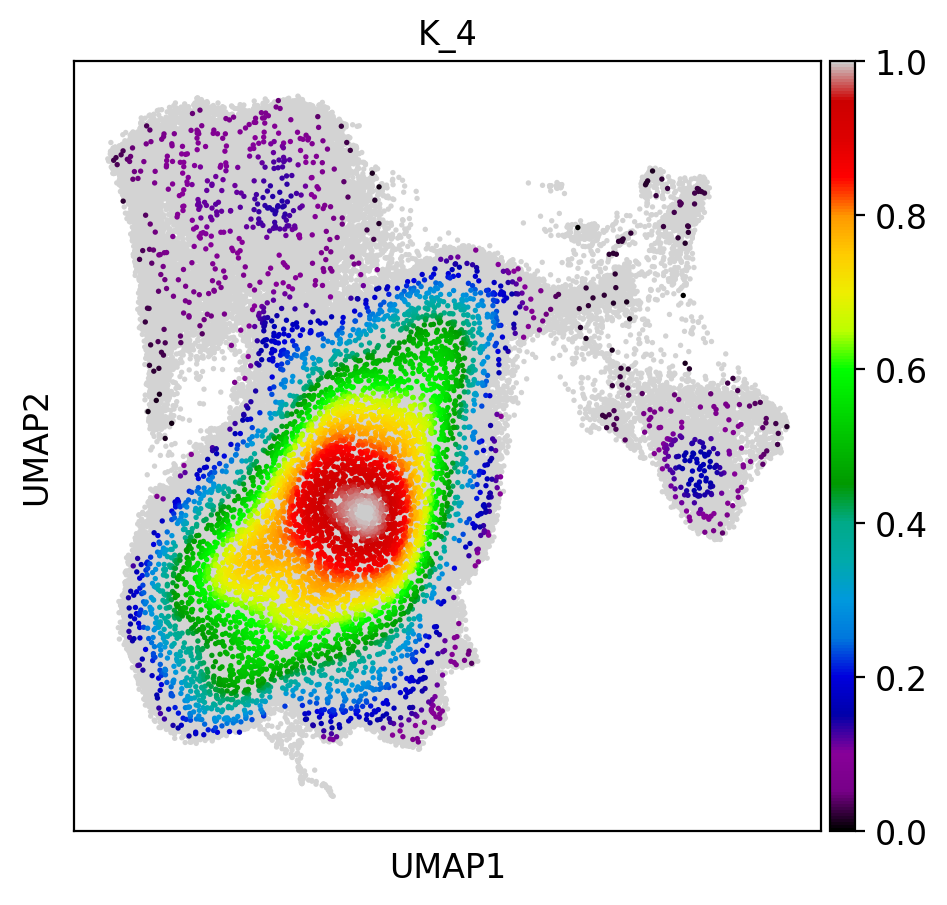

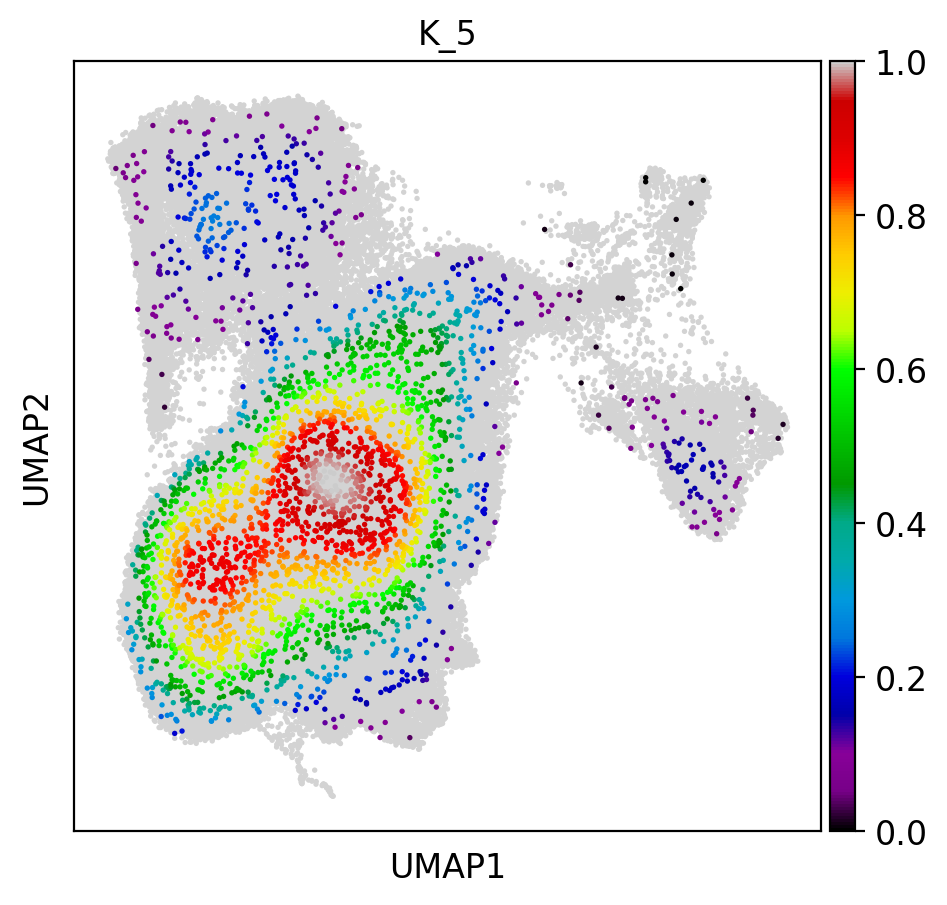

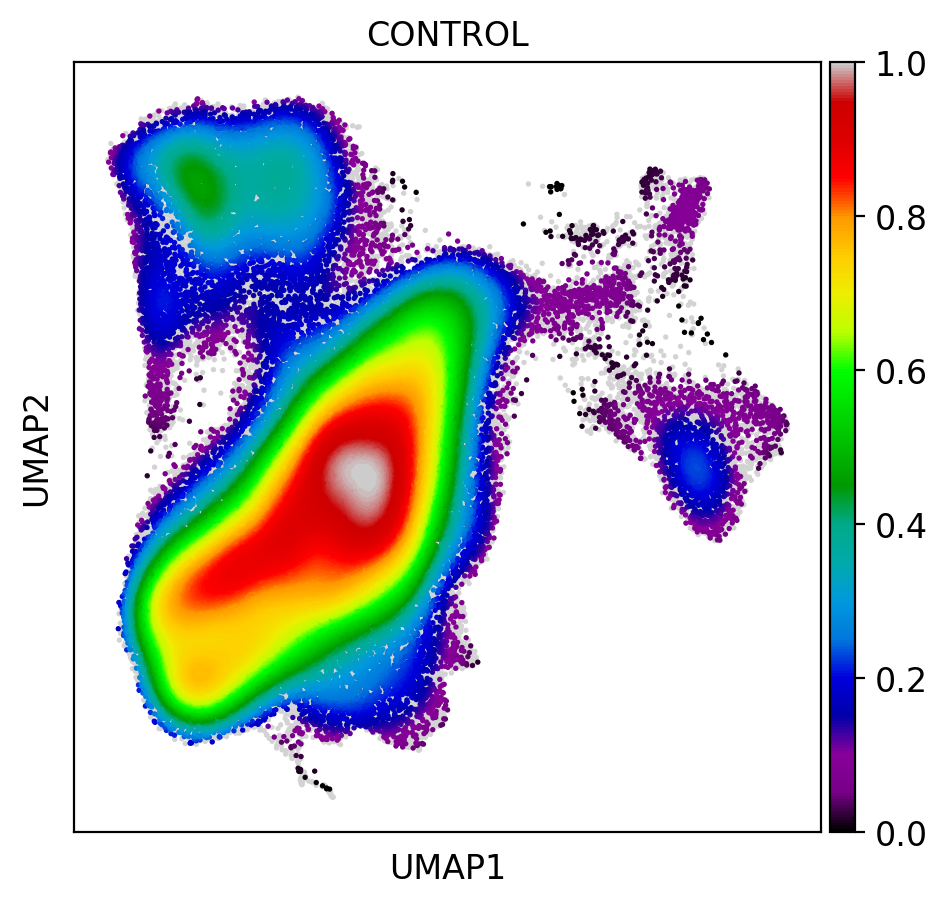

In [8]:
for group in GROUPS:
    fig = sc.pl.embedding_density(
        adata,
        key=f"umap_density_{group}",
        group="1",
        color_map="nipy_spectral",
        bg_dotsize=15,
        fg_dotsize=15,
        title="CONTROL" if group == "K_CONTROL" else group,
        return_fig=True,
    )
    fig.set_size_inches(*PANEL_SIZE)
    fig.savefig(FIGURE_DIR / f"umap_density_{group}.pdf")
    display(fig)          # return_fig suppresses scanpy's own display
    plt.close(fig)        # ...and stop the inline backend showing it a second time